# NB1 — Data Loading, Cruise Extraction & Fault Injection
## Jet Engine PHM — N-CMAPSS Multi-Dataset Pipeline

**Purpose:** Load all N-CMAPSS `.h5` datasets, calibrate cruise threshold, extract nominal cruise windows,
fit the global MinMaxScaler, inject faults for all 4 cases, and save everything to disk.

**Outputs saved:**
- `processed_data/X_nominal.npy` — scaled nominal cruise windows `(N, 50, 14)`
- `processed_data/sensor_cols.pkl` — sensor column names list
- `checkpoints/global_scaler.pkl` — fitted MinMaxScaler
- `processed_data/augmented_dataset.npz` — full fault-injected dataset `X, y_f, y_s, y_m`
- `processed_data/sensor_metadata.pkl` — sensor metadata
- `plots/nb1_flight_profile.png`, `plots/nb1_cruise_calib.png`, `plots/nb1_fault_cases.png`

## 0. Environment Setup

In [1]:
# ─── Install dependencies (run once) ─────────────────────────────────────────
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip install h5py numpy pandas matplotlib scipy scikit-learn umap-learn shap tqdm jupyter

import sys, os, gc, logging, warnings, pickle
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm
from sklearn.preprocessing import MinMaxScaler

# ─── Local modules (must be in same directory) ────────────────────────────────
sys.path.insert(0, '..')
from data_utils   import NCMAPSSLoader, extract_cruise_mask, SENSOR_COLS
from fault_engine import FaultEngine, FAULT_LABELS

# ─── GPU check ────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('✓ Environment ready')

2026-04-20 14:03:16,510 [INFO] NumExpr defaulting to 12 threads.


PyTorch : 2.5.1+cu124
Device  : cuda
GPU     : NVIDIA RTX 4500 Ada Generation
VRAM    : 25.8 GB
✓ Environment ready


## 1. Configuration

In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# Update DATA_DIR to point to your N-CMAPSS .h5 files (DS01-005.h5 … DS08a-005.h5)
# ──────────────────────────────────────────────────────────────────────────────
DATA_DIR      = '../data/ncmapss'      # Directory containing all *.h5 files
PROC_DIR      = '../processed_data'    # Where to save processed arrays
CKPT_DIR      = '../checkpoints'       # Where to save scalers and models
PLOT_DIR      = '../plots'

for d in [PROC_DIR, CKPT_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Window / Cruise parameters ────────────────────────────────────────────────
WINDOW_SIZE   = 50      # seconds @ 1 Hz
STRIDE        = 10      # seconds
N_SENSORS     = 14      # X_s columns (T24, T30, T48, T50, P15, P2, P21, P24,
                        #              Ps30, P40, P50, Nf, Nc, Wf)

# ── Fault injection parameters ───────────────────────────────────────────────
FAULT_RATIO   = 1.00    # inject on EVERY nominal window — natural ceiling for balanced dataset
FAULT_SEED    = 42

print('Configuration set.')
print(f'  DATA_DIR  : {DATA_DIR}')
print(f'  PROC_DIR  : {PROC_DIR}')
print(f'  CKPT_DIR  : {CKPT_DIR}')

Configuration set.
  DATA_DIR  : ../data/ncmapss
  PROC_DIR  : ../processed_data
  CKPT_DIR  : ../checkpoints


## 2. Initialize Loader & Auto-Calibrate Cruise Threshold

The `NCMAPSSLoader` reads altitude columns from all `.h5` files and derives the cruise threshold
automatically using the **Cruise-Fraction Percentile Method** — no hard-coded value needed.

In [4]:
loader = NCMAPSSLoader(
    data_dir     = DATA_DIR,
    window_size  = WINDOW_SIZE,
    stride       = STRIDE,
    # cruise_std_th = None  ←  auto-calibrate from dataset (recommended)
    # cruise_std_th = 75.0  ←  uncomment to fix a value manually
)

CRUISE_STD_TH = loader.cruise_std_th
print(f'HDF5 files found          : {len(loader.h5_files)}')
for f in loader.h5_files:
    print(f'  {f.name}')
print(f'Auto-calibrated threshold : {CRUISE_STD_TH:.2f} ft')

2026-04-06 14:11:16,358 [INFO] NCMAPSSLoader: found 1 file(s) in ..\data\ncmapss
2026-04-06 14:11:16,359 [INFO] Calibrating cruise threshold from dataset …
2026-04-06 14:12:51,969 [INFO] calibrate_cruise_threshold: threshold=65.9 ft  (P50=32.9 ft × margin=2.0, n_flights=2)
2026-04-06 14:12:52,036 [INFO] Auto-calibrated cruise_std_th = 65.9 ft


HDF5 files found          : 1
  N-CMAPSS_DS01-005.h5
Auto-calibrated threshold : 65.87 ft


### 2a. Visualise Calibration Diagnostic

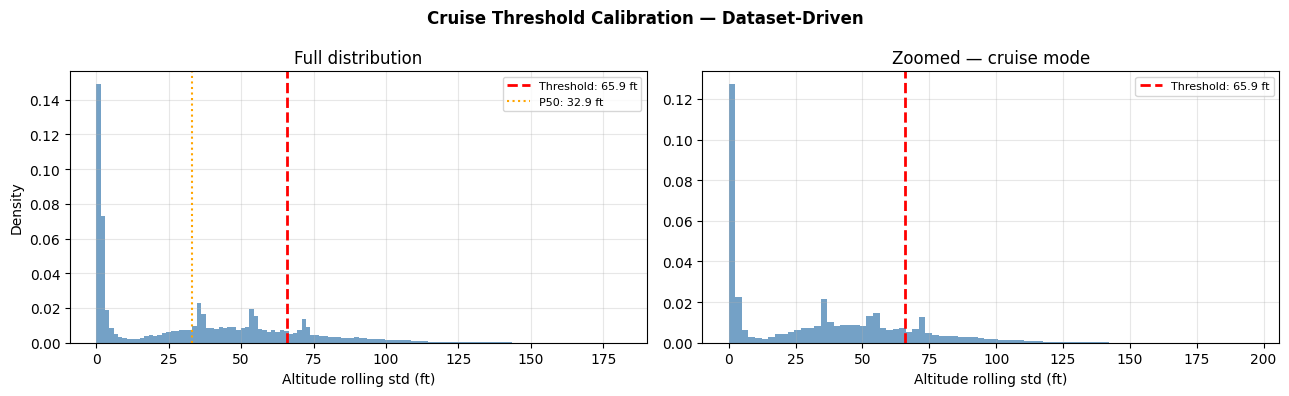

Calibration diagnostics: p50=32.9  p75=55.1  p95=90.5


In [5]:
if loader.calib_diag:
    diag = loader.calib_diag
    rs   = diag['rolling_std_sample']

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Cruise Threshold Calibration — Dataset-Driven', fontweight='bold')

    # Left: full rolling-std histogram
    axes[0].hist(rs[rs < diag['p95']*2], bins=120,
                 color='steelblue', edgecolor='none', alpha=0.75, density=True)
    axes[0].axvline(CRUISE_STD_TH, color='red', lw=2, ls='--',
                    label=f'Threshold: {CRUISE_STD_TH:.1f} ft')
    axes[0].axvline(diag['p50'],   color='orange', lw=1.5, ls=':',
                    label=f'P50: {diag["p50"]:.1f} ft')
    axes[0].set_xlabel('Altitude rolling std (ft)'); axes[0].set_ylabel('Density')
    axes[0].set_title('Full distribution'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    # Right: zoomed into cruise mode
    zoom_max = CRUISE_STD_TH * 3
    axes[1].hist(rs[rs < zoom_max], bins=80,
                 color='steelblue', edgecolor='none', alpha=0.75, density=True)
    axes[1].axvline(CRUISE_STD_TH, color='red', lw=2, ls='--', label=f'Threshold: {CRUISE_STD_TH:.1f} ft')
    axes[1].set_xlabel('Altitude rolling std (ft)'); axes[1].set_title('Zoomed — cruise mode')
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/nb1_cruise_calib.png', dpi=120)
    plt.show()
    print(f'Calibration diagnostics: p50={diag["p50"]:.1f}  p75={diag["p75"]:.1f}  p95={diag["p95"]:.1f}')

### 2b. Visualise Representative Flight Profile

2026-04-06 14:12:52,961 [INFO] Loading Full Dataset: N-CMAPSS_DS01-005.h5


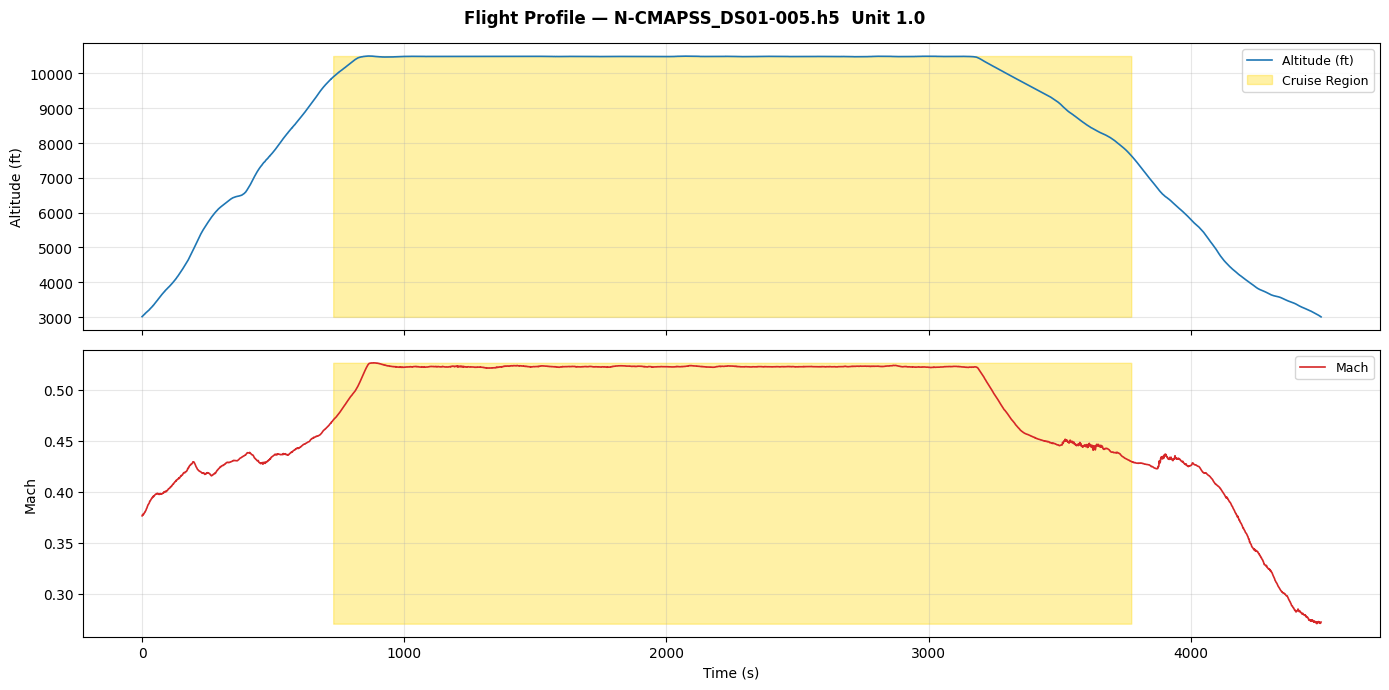

Cruise samples: 3045/4498


In [6]:
first_batch = next(loader.iter_files(cruise_only=False))
df_flight   = first_batch['df']
cmask       = first_batch['cruise_mask']

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
t = np.arange(len(df_flight))

axes[0].plot(t, df_flight['alt'], color='#1f77b4', lw=1.2, label='Altitude (ft)')
axes[0].fill_between(t, df_flight['alt'].min(), df_flight['alt'].max(),
                      where=cmask, color='gold', alpha=0.35, label='Cruise Region')
axes[0].set_ylabel('Altitude (ft)'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(t, df_flight['Mach'], color='#d62728', lw=1.2, label='Mach')
axes[1].fill_between(t, df_flight['Mach'].min(), df_flight['Mach'].max(),
                      where=cmask, color='gold', alpha=0.35)
axes[1].set_ylabel('Mach'); axes[1].set_xlabel('Time (s)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

fig.suptitle(f'Flight Profile — {first_batch["file"]}  Unit {first_batch["unit"]}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb1_flight_profile.png', dpi=120)
plt.show()
print(f'Cruise samples: {cmask.sum()}/{len(cmask)}')

## 3. Global MinMaxScaler Fitting (Phase 1 of 2)

Subsample 10% of sensor readings from every unit-cycle across **all** datasets
to build a dataset-wide scaler. This ensures consistent `[0, 1]` scaling
regardless of which DS files are included.

In [7]:
global_scaler = MinMaxScaler(feature_range=(0, 1))
pooled_samples = []

print('Phase 1: Scanning all DS files for global min/max …')
for batch in tqdm(loader.iter_files(cruise_only=True, nominal_only=False),
                  desc='Global scaler fit'):
    df_sensors = batch['df'][SENSOR_COLS]
    if len(df_sensors) > 0:
        sample = df_sensors.sample(frac=0.10, random_state=0).values.astype(np.float32)
        pooled_samples.append(sample)

X_stack = np.vstack(pooled_samples)
global_scaler.fit(X_stack)
del X_stack, pooled_samples; gc.collect()

# Save scaler
with open(f'{CKPT_DIR}/global_scaler.pkl', 'wb') as f:
    pickle.dump(global_scaler, f)
print(f'Global scaler fitted → saved to {CKPT_DIR}/global_scaler.pkl')
print(f'  Data min (per sensor): {global_scaler.data_min_}')
print(f'  Data max (per sensor): {global_scaler.data_max_}')

Phase 1: Scanning all DS files for global min/max …


Global scaler fit: 0it [00:00, ?it/s]2026-04-06 14:13:05,162 [INFO] Loading Full Dataset: N-CMAPSS_DS01-005.h5
Global scaler fit: 894it [03:39,  4.07it/s]

Global scaler fitted → saved to ../checkpoints/global_scaler.pkl
  Data min (per sensor): [4.8422461e+02 1.0737406e+03 1.2426426e+03 8.9093402e+02 5.9175959e+00
 4.3920050e+00 6.0077114e+00 6.9144239e+00 8.0573318e+01 8.2316750e+01
 4.1471395e+00 1.4998544e+03 7.3730176e+03 6.7961347e-01]
  Data max (per sensor): [6.1231799e+02 1.4607762e+03 1.8904152e+03 1.2723916e+03 1.8037054e+01
 1.4570217e+01 1.8311731e+01 2.2342358e+01 3.6030392e+02 3.6623621e+02
 1.5145751e+01 2.2122588e+03 8.6622480e+03 4.2053676e+00]


## 4. Collect Nominal Cruise Windows (Phase 2 of 2)

Iterate all datasets again, extract `hs==1` cruise-phase windows, and apply
the fitted global scaler on-the-fly. The result is the training pool for the
Autoencoder.

In [8]:
print('Phase 2: Loading & scaling nominal cruise windows …')
X_nominal, sensor_cols = loader.collect_nominal_cruise_windows(scaler=global_scaler)

print('-' * 55)
print(f'X_nominal shape   : {X_nominal.shape}   dtype={X_nominal.dtype}')
print(f'Sensors           : {sensor_cols}')
print(f'Memory footprint  : {X_nominal.nbytes / 1e6:.1f} MB')
print(f'Scaled range      : {X_nominal.min():.4f} → {X_nominal.max():.4f}')
assert X_nominal.min() >= -0.0107 and X_nominal.max() <= 1.01, 'Scaling check failed!'
print('✓ Scale check passed')

2026-04-06 14:16:44,809 [INFO] Loading Full Dataset: N-CMAPSS_DS01-005.h5


Phase 2: Loading & scaling nominal cruise windows …


2026-04-06 14:19:13,522 [INFO] Nominal cruise windows: (120506, 50, 14) (Scaled: True)


-------------------------------------------------------
X_nominal shape   : (120506, 50, 14)   dtype=float32
Sensors           : ['T24', 'T30', 'T48', 'T50', 'P15', 'P2', 'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf']
Memory footprint  : 337.4 MB
Scaled range      : -0.0107 → 1.0079
✓ Scale check passed


## 5. Save Nominal Windows & Sensor Metadata

In [9]:
np.save(f'{PROC_DIR}/X_nominal.npy', X_nominal)
with open(f'{PROC_DIR}/sensor_cols.pkl', 'wb') as f:
    pickle.dump(sensor_cols, f)

print(f'Saved X_nominal    → {PROC_DIR}/X_nominal.npy')
print(f'Saved sensor_cols  → {PROC_DIR}/sensor_cols.pkl')
print(f'Shape: {X_nominal.shape}')

Saved X_nominal    → ../processed_data/X_nominal.npy
Saved sensor_cols  → ../processed_data/sensor_cols.pkl
Shape: (120506, 50, 14)


## 6. Fault Injection — All Four Cases

> **Note on fault magnitudes:** This version uses **significantly larger magnitudes**
> (20–60% of signal range for bias/scaling/drift; 0.5–2.0×std for intermittent)
> compared to the original single-dataset version. This ensures faults are clearly
> distinguishable after MinMaxScaling.

In [10]:
engine = FaultEngine(seed=FAULT_SEED)
print(engine.summary())

2026-04-06 14:19:14,005 [INFO] FaultEngine initialized (seed=42, fs=1 Hz) | mag_range=[0.40, 0.80] | interm_range=[0.50, 2.00]


FaultEngine – Supported Fault Cases  [Multi-Dataset Version]
Case 1 (Single Sensor, Single Fault):
  • Bias          – additive constant offset  (mag = 20–60% of range)
  • Scaling       – multiplicative gain error (mag = 20–60%)
  • Drift         – linearly increasing ramp  (mag = 20–60% of range)
  • Intermittent  – random pulse spikes       (mag = 0.5–2.0 × std, prob=0.25)

Case 2 (Single Sensor, Multi-Fault):
  • Compound      – sequential fault composition

Case 3 (Multi-Sensor Faults):
  • MultiSensor   – independent faults on ≥2 channels

Case 4 (System Fault):
  • SystemFault   – N-CMAPSS physical degradation (hs, RUL)

NOTE: Magnitudes significantly increased vs. original single-dataset
      version to ensure clear detectability after MinMaxScaling.


### 6a. Visualise All Four Fault Types (Case 1)

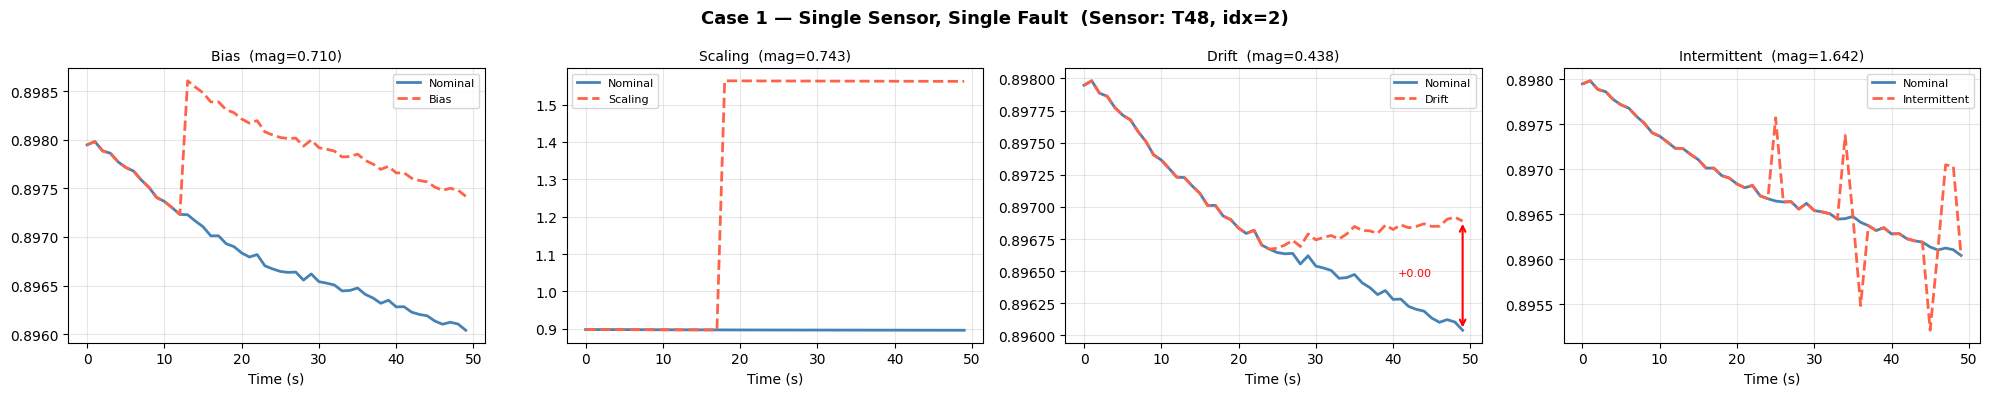

In [11]:
sample_win  = X_nominal[0].copy()
fault_types = ['bias', 'scaling', 'drift', 'intermittent']
SENSOR_DEMO = 2   # T48

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle(f'Case 1 — Single Sensor, Single Fault  (Sensor: {sensor_cols[SENSOR_DEMO]}, idx={SENSOR_DEMO})',
             fontsize=13, fontweight='bold')

for ax, ft in zip(axes, fault_types):
    w_f, si, lbl, _, mag = engine.inject_single_sensor_single_fault(
        sample_win, fault_type=ft, sensor_idx=SENSOR_DEMO
    )
    ax.plot(sample_win[:, SENSOR_DEMO], label='Nominal', color='steelblue', lw=2)
    ax.plot(w_f[:, SENSOR_DEMO],        label=ft.capitalize(), color='tomato', lw=2, ls='--')
    if ft == 'drift':
        sep = abs(w_f[-1, SENSOR_DEMO] - sample_win[-1, SENSOR_DEMO])
        ax.annotate('', xy=(49, w_f[-1, SENSOR_DEMO]), xytext=(49, sample_win[-1, SENSOR_DEMO]),
                    arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
        ax.text(45, (w_f[-1, SENSOR_DEMO] + sample_win[-1, SENSOR_DEMO]) / 2,
                f'+{sep:.2f}', color='red', fontsize=8, ha='right')
    ax.set_title(f'{ft.capitalize()}  (mag={mag:.3f})', fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb1_fault_cases.png', dpi=120)
plt.show()

### 6b. Visualise Case 2 (Compound) & Case 3 (Multi-Sensor)

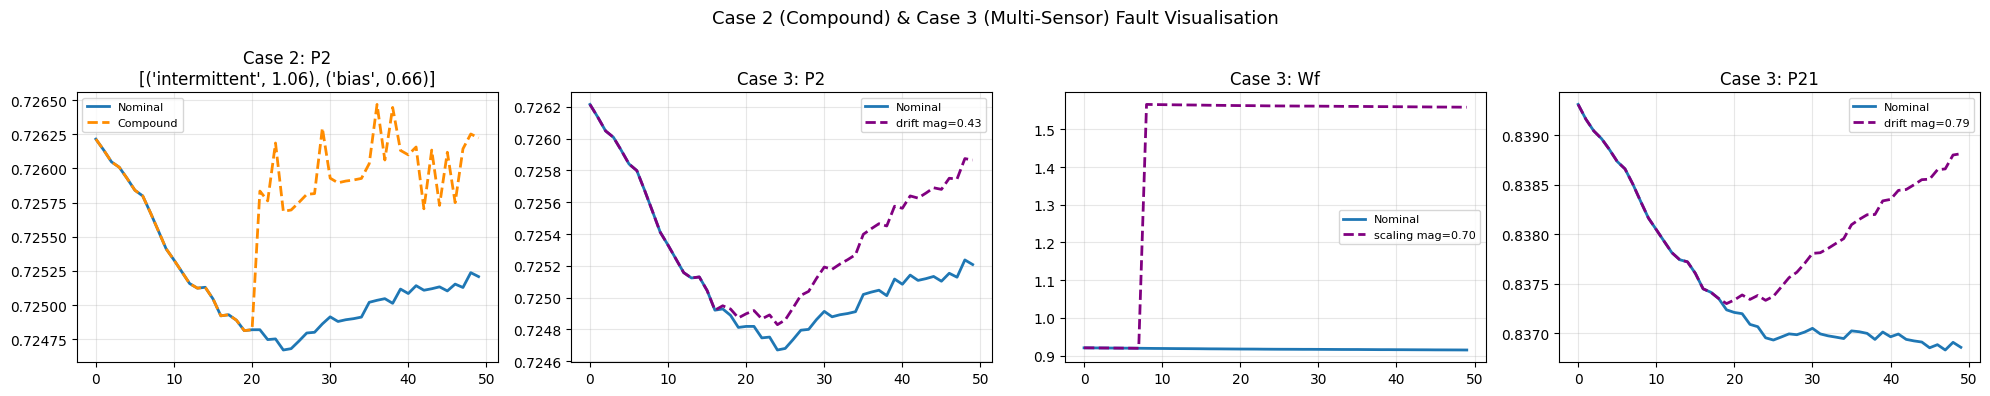

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Case 2 (Compound) & Case 3 (Multi-Sensor) Fault Visualisation', fontsize=13)

# Case 2 – compound fault
w_c, si_c, lbl_c, seq_c = engine.inject_compound_fault(sample_win, sensor_idx=5)
axes[0].plot(sample_win[:, 5], label='Nominal', lw=2)
axes[0].plot(w_c[:, 5], label='Compound', lw=2, ls='--', color='darkorange')
axes[0].set_title(f'Case 2: {sensor_cols[5]}\n{[(s[0],round(s[1],2)) for s in seq_c]}')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Case 3 – multi-sensor faults
w_ms, specs_ms = engine.inject_multi_sensor_faults(sample_win, n_affected=3)
for ax, spec in zip(axes[1:], specs_ms):
    s = spec.sensor_idx
    ax.plot(sample_win[:, s], label='Nominal', lw=2)
    ax.plot(w_ms[:, s], label=f'{spec.fault_type} mag={spec.magnitude:.2f}', lw=2, ls='--', color='purple')
    ax.set_title(f'Case 3: {sensor_cols[s]}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb1_compound_multisensor.png', dpi=120)
plt.show()

## 7. Build Augmented Dataset (Nominal + All Fault Cases)

In [13]:
X_nominal = np.load(f'{PROC_DIR}/X_nominal.npy')

In [14]:
with open(f'{PROC_DIR}/sensor_cols.pkl', 'rb') as f:
    sensor_cols = pickle.load(f)

In [15]:
X_all   = [X_nominal]
y_fault = [np.zeros(len(X_nominal), dtype=np.int64)]
y_sensor= [np.zeros(len(X_nominal), dtype=np.int64)]
y_mag   = [np.zeros(len(X_nominal), dtype=np.float32)]

from fault_engine import FAULT_LABELS, FAULT_LABEL_TO_INT

rng_inj = np.random.default_rng(FAULT_SEED)

for case in [1, 2, 3]:
    print(f'  Injecting Case {case} faults (ratio={FAULT_RATIO}) …')
    N = len(X_nominal)
    n_faulty = int(N * FAULT_RATIO)
    indices  = rng_inj.choice(N, size=n_faulty, replace=False)

    X_case  = X_nominal.copy()
    yf_case = np.zeros(N, dtype=np.int64)
    ys_case = np.zeros(N, dtype=np.int64)
    ym_case = np.zeros(N, dtype=np.float32)

    for i in indices:
        win = X_case[i]
        if case == 1:
            win_f, s_idx, lbl, _, mag = engine.inject_single_sensor_single_fault(win)
            X_case[i]  = win_f
            yf_case[i] = lbl
            ys_case[i] = int(s_idx)          # ← real sensor index, not random
            ym_case[i] = float(mag)
        elif case == 2:
            win_f, s_idx, lbl, seq = engine.inject_compound_fault(win)
            X_case[i]  = win_f
            yf_case[i] = lbl
            ys_case[i] = int(s_idx)          # ← real sensor index
            ym_case[i] = float(np.mean([s[1] for s in seq]))  # mean magnitude of sequence
        elif case == 3:
            win_f, specs = engine.inject_multi_sensor_faults(win)
            X_case[i]  = win_f
            yf_case[i] = FAULT_LABEL_TO_INT['MultiSensor']
            ys_case[i] = int(specs[0].sensor_idx)   # primary faulted sensor
            ym_case[i] = float(specs[0].magnitude)

    faulty_mask = yf_case > 0
    X_all.append(X_case[faulty_mask])
    y_fault.append(yf_case[faulty_mask])
    y_sensor.append(ys_case[faulty_mask])
    y_mag.append(ym_case[faulty_mask])
    print(f'    Injected {faulty_mask.sum():,} / {N:,} windows')


X_dataset = np.concatenate(X_all, axis=0)
y_fault   = np.concatenate(y_fault).astype(np.int64)
y_sensor  = np.concatenate(y_sensor).astype(np.int64)
y_mag     = np.concatenate(y_mag).astype(np.float32)

print(f'\nAugmented dataset shape : {X_dataset.shape}')
labels, counts = np.unique(y_fault, return_counts=True)
label_names = {0:'Nominal',1:'Bias',2:'Scaling',3:'Drift',4:'Intermittent',5:'Compound',6:'MultiSensor',7:'SystemFault'}
print('Class distribution:')
for l, c in zip(labels, counts):
    print(f'  {label_names.get(l,str(l)):15s}: {c:>8,}')

# ── Balance all classes to natural Case 1 yield ──────────────────────────────
# Case 1 injects 4 fault types equally. Their count is the natural ceiling
# (FAULT_RATIO=1.0 means every nominal window gets one fault injected).
# We cap Nominal, Compound, and MultiSensor to match this ceiling.
labels_arr, label_counts = np.unique(y_fault, return_counts=True)
case1_type_counts = [label_counts[labels_arr == c][0]
                     for c in [1, 2, 3, 4] if c in labels_arr]
TARGET_PER_CLASS = int(np.mean(case1_type_counts))   # ~30,126 at FAULT_RATIO=1.0

rng_bal  = np.random.default_rng(FAULT_SEED + 1)
keep_idx = []
for cls in np.unique(y_fault):
    cls_idx = np.where(y_fault == cls)[0]
    if len(cls_idx) > TARGET_PER_CLASS:
        chosen = rng_bal.choice(cls_idx, TARGET_PER_CLASS, replace=False)
    else:
        chosen = cls_idx   # keep all (Bias/Scaling/Drift/Intermittent already at target)
    keep_idx.append(chosen)

keep_idx  = np.concatenate(keep_idx)
rng_bal.shuffle(keep_idx)

X_dataset = X_dataset[keep_idx]
y_fault   = y_fault[keep_idx]
y_sensor  = y_sensor[keep_idx]
y_mag     = y_mag[keep_idx]

print(f'\nTARGET_PER_CLASS = {TARGET_PER_CLASS:,}')
print(f'After balancing — shape : {X_dataset.shape}')
print('Class distribution (before SystemFault):')
for l, c in zip(*np.unique(y_fault, return_counts=True)):
    print(f'  {label_names.get(l, str(l)):15s}: {c:>8,}')


  Injecting Case 1 faults (ratio=1.0) …
    Injected 120,506 / 120,506 windows
  Injecting Case 2 faults (ratio=1.0) …
    Injected 120,506 / 120,506 windows
  Injecting Case 3 faults (ratio=1.0) …
    Injected 120,506 / 120,506 windows

Augmented dataset shape : (482024, 50, 14)
Class distribution:
  Nominal        :  120,506
  Bias           :   29,958
  Scaling        :   30,259
  Drift          :   30,341
  Intermittent   :   29,948
  Compound       :  120,506
  MultiSensor    :  120,506

TARGET_PER_CLASS = 30,126
After balancing — shape : (210536, 50, 14)
Class distribution (before SystemFault):
  Nominal        :   30,126
  Bias           :   29,958
  Scaling        :   30,126
  Drift          :   30,126
  Intermittent   :   29,948
  Compound       :   30,126
  MultiSensor    :   30,126


## 8. Case 4 — System Fault Labels from N-CMAPSS Metadata

In [16]:
import pandas as pd

all_meta_frames = []
print('Scanning metadata for hs and RUL columns …')
for batch in tqdm(loader.iter_files(cruise_only=False, nominal_only=False, only_metadata=True),
                  desc='Case 4 metadata'):
    df_b = batch['df']
    if 'hs' not in df_b.columns or 'RUL' not in df_b.columns:
        continue
    all_meta_frames.append(df_b[['hs', 'RUL', 'unit']].copy())

if all_meta_frames:
    df_meta = pd.concat(all_meta_frames, ignore_index=True); gc.collect()
    print(f'Metadata rows   : {len(df_meta):,}')
    print(f'Unique units    : {df_meta["unit"].nunique()}')
    print(f'hs distribution :\n{df_meta["hs"].value_counts().to_string()}')

    # Adaptive AND logic: hs==0 AND RUL in last 20% of life
    df_meta['unit_max_rul'] = df_meta.groupby('unit')['RUL'].transform('max')
    df_meta['rul_frac']     = df_meta['RUL'] / (df_meta['unit_max_rul'] + 1e-8)
    sys_fault_labels = ((df_meta['hs'] == 0) & (df_meta['rul_frac'] < 0.20)).astype(int).values
    print(f'\nSystem fault labels: {sys_fault_labels.sum():,} / {len(sys_fault_labels):,} rows')
else:
    print('No hs/RUL columns found. Case 4 labels not available for this dataset.')
    sys_fault_labels = None

Scanning metadata for hs and RUL columns …


Case 4 metadata: 894it [00:01, 543.78it/s] 


Metadata rows   : 7,641,868
Unique units    : 10
hs distribution :
hs
0.0    5587087
1.0    2054781

System fault labels: 1,513,760 / 7,641,868 rows


In [17]:
# ── Cell 8b — Case 4: Extract & append SystemFault windows ──────────────────
#
# iter_files yields:
#   batch['windows'] : (N_wins, T, S)  unscaled sensor data
#   batch['hs']      : (n_timesteps,)  one value per raw timestep
#
# We label window i as SystemFault if its centre timestep has hs == 0.
# hs is binary (0=degraded, 1=nominal) so centre-timestep labelling is exact.

if sys_fault_labels is not None:
    print('Case 4: Extracting SystemFault windows …')

    SYSTEM_FAULT_LABEL = 7
    CENTRE_OFFSET      = loader.window_size // 2   # 25 for window_size=50

    X_sf_chunks   = []
    y_sf_fault_l  = []
    y_sf_sensor_l = []
    y_sf_mag_l    = []

    for batch in tqdm(
        loader.iter_files(cruise_only=False, nominal_only=False, only_metadata=False),
        desc='Case 4 windows'
    ):
        hs_vals = batch.get('hs')
        wins    = batch.get('windows')   # (N_wins, T, S) — unscaled

        if hs_vals is None or wins is None or len(wins) == 0:
            continue

        N_wins = len(wins)
        n_ts   = len(hs_vals)

        # Centre timestep for each window
        centre_idx = np.array([i * loader.stride + CENTRE_OFFSET for i in range(N_wins)])
        valid      = centre_idx < n_ts
        wins       = wins[valid]
        centre_idx = centre_idx[valid]

        # SystemFault window = centre timestep has hs == 0
        win_hs  = hs_vals[centre_idx]
        sf_mask = (win_hs == 0)

        if sf_mask.sum() == 0:
            continue

        X_sf = wins[sf_mask]             # (n_sf, T, S) — unscaled
        N_sf, T, S = X_sf.shape

        # Scale with the already-fitted global scaler
        X_sf_scaled = global_scaler.transform(
            X_sf.reshape(-1, S)
        ).reshape(N_sf, T, S).astype(np.float32)

        X_sf_chunks.append(X_sf_scaled)
        # sensor_id=0: system-level fault, no single sensor responsible
        # magnitude=0.5: fixed proxy for physical degradation
        y_sf_fault_l.append(np.full(N_sf, SYSTEM_FAULT_LABEL, dtype=np.int64))
        y_sf_sensor_l.append(np.zeros(N_sf, dtype=np.int64))
        y_sf_mag_l.append(np.full(N_sf, 0.5, dtype=np.float32))

    if X_sf_chunks:
        X_sf_all       = np.concatenate(X_sf_chunks)
        y_sf_fault_np  = np.concatenate(y_sf_fault_l)
        y_sf_sensor_np = np.concatenate(y_sf_sensor_l)
        y_sf_mag_np    = np.concatenate(y_sf_mag_l)

        print(f'SystemFault windows extracted (raw) : {len(X_sf_all):,}')

        # Cap at TARGET_PER_CLASS to match all other classes exactly
        if len(X_sf_all) > TARGET_PER_CLASS:
            rng_sf        = np.random.default_rng(FAULT_SEED + 2)
            idx_sf        = rng_sf.choice(len(X_sf_all), TARGET_PER_CLASS, replace=False)
            X_sf_all      = X_sf_all[idx_sf]
            y_sf_fault_np = y_sf_fault_np[idx_sf]
            y_sf_sensor_np= y_sf_sensor_np[idx_sf]
            y_sf_mag_np   = y_sf_mag_np[idx_sf]

        # Append to dataset
        X_dataset = np.concatenate([X_dataset, X_sf_all],        axis=0)
        y_fault   = np.concatenate([y_fault,   y_sf_fault_np])
        y_sensor  = np.concatenate([y_sensor,  y_sf_sensor_np])
        y_mag     = np.concatenate([y_mag,     y_sf_mag_np])

        print(f'SystemFault windows kept            : {len(X_sf_all):,}')
        print(f'\nFinal dataset shape : {X_dataset.shape}')
        print('Final class distribution:')
        for l, c in zip(*np.unique(y_fault, return_counts=True)):
            print(f'  {label_names.get(l, str(l)):15s}: {c:>8,}')
    else:
        print('WARNING: No SystemFault windows extracted. Check hs column.')
else:
    print('sys_fault_labels is None — skipping Case 4.')


Case 4: Extracting SystemFault windows …


Case 4 windows: 0it [00:00, ?it/s]2026-04-06 14:19:48,372 [INFO] Loading Full Dataset: N-CMAPSS_DS01-005.h5
Case 4 windows: 894it [03:45,  3.96it/s]


SystemFault windows extracted (raw) : 555,935
SystemFault windows kept            : 30,126

Final dataset shape : (240662, 50, 14)
Final class distribution:
  Nominal        :   30,126
  Bias           :   29,958
  Scaling        :   30,126
  Drift          :   30,126
  Intermittent   :   29,948
  Compound       :   30,126
  MultiSensor    :   30,126
  SystemFault    :   30,126


## 9. Save Augmented Dataset

In [18]:
np.savez_compressed(
    f'{PROC_DIR}/augmented_dataset.npz',
    X   = X_dataset,
    y_f = y_fault,
    y_s = y_sensor,
    y_m = y_mag,
)
with open(f'{PROC_DIR}/sensor_metadata.pkl', 'wb') as f:
    pickle.dump(sensor_cols, f)

print(f'Saved augmented_dataset.npz  → {PROC_DIR}/')
print(f'  X      : {X_dataset.shape}  ({X_dataset.nbytes/1e9:.2f} GB)')
print(f'  y_fault: {y_fault.shape}')
print(f'  y_sensor:{y_sensor.shape}')
print(f'  y_mag  : {y_mag.shape}')
print('\n✓ NB1 complete — all data saved. Proceed to NB2_Autoencoder.ipynb')

Saved augmented_dataset.npz  → ../processed_data/
  X      : (240662, 50, 14)  (0.67 GB)
  y_fault: (240662,)
  y_sensor:(240662,)
  y_mag  : (240662,)

✓ NB1 complete — all data saved. Proceed to NB2_Autoencoder.ipynb
